<a href="https://colab.research.google.com/github/grehna29/AI-ML-Lab/blob/main/AI_ML_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab Exercise I: Data Pre-processing(14/07/2026)

In [3]:
#uploading the dataset
from google.colab import files
uploaded = files.upload()

Saving Alzheimer_Dataset_Details.csv to Alzheimer_Dataset_Details (1).csv


In [4]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

1.

In [9]:
#1. Load the dataset and display its basic information
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("Alzheimer_Dataset_Details.csv")

# Display dataset
print(df.head())

# Basic Information
print(df.info())

print(df.describe(include='all'))

   Split        Disease      Filename Extension  Width  Height  Channels  \
0  train  Mild_Demented   mild_10.jpg      .jpg    128     128         1   
1  train  Mild_Demented  mild_100.jpg      .jpg    128     128         1   
2  train  Mild_Demented  mild_102.jpg      .jpg    128     128         1   
3  train  Mild_Demented  mild_103.jpg      .jpg    128     128         1   
4  train  Mild_Demented  mild_106.jpg      .jpg    128     128         1   

  Color Mode  File Size (KB)  File Size (MB)  \
0          L            4.08          0.0040   
1          L            3.95          0.0039   
2          L            3.92          0.0038   
3          L            3.95          0.0039   
4          L            4.02          0.0039   

                                           Full Path  
0  C:\Users\mohib\Desktop\Alzheimer_Split\train\M...  
1  C:\Users\mohib\Desktop\Alzheimer_Split\train\M...  
2  C:\Users\mohib\Desktop\Alzheimer_Split\train\M...  
3  C:\Users\mohib\Desktop\Alzheime

In [10]:
#2. Identify the number of rows, columns, data types, and missing values in the dataset
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Number of Rows : 6336
Number of Columns : 11

Data Types:
Split              object
Disease            object
Filename           object
Extension          object
Width               int64
Height              int64
Channels            int64
Color Mode         object
File Size (KB)    float64
File Size (MB)    float64
Full Path          object
dtype: object

Missing Values:
Split             0
Disease           0
Filename          0
Extension         0
Width             0
Height            0
Channels          0
Color Mode        0
File Size (KB)    0
File Size (MB)    0
Full Path         0
dtype: int64


In [11]:
#3. Perform exploratory data inspection by displaying the first, last, and randomly selected records of the dataset
print("First 5 Records")
print(df.head())

print("\nLast 5 Records")
print(df.tail())

print("\nRandom 5 Records")
print(df.sample(5))

First 5 Records
   Split        Disease      Filename Extension  Width  Height  Channels  \
0  train  Mild_Demented   mild_10.jpg      .jpg    128     128         1   
1  train  Mild_Demented  mild_100.jpg      .jpg    128     128         1   
2  train  Mild_Demented  mild_102.jpg      .jpg    128     128         1   
3  train  Mild_Demented  mild_103.jpg      .jpg    128     128         1   
4  train  Mild_Demented  mild_106.jpg      .jpg    128     128         1   

  Color Mode  File Size (KB)  File Size (MB)  \
0          L            4.08          0.0040   
1          L            3.95          0.0039   
2          L            3.92          0.0038   
3          L            3.95          0.0039   
4          L            4.02          0.0039   

                                           Full Path  
0  C:\Users\mohib\Desktop\Alzheimer_Split\train\M...  
1  C:\Users\mohib\Desktop\Alzheimer_Split\train\M...  
2  C:\Users\mohib\Desktop\Alzheimer_Split\train\M...  
3  C:\Users\mohib\

In [14]:
#4. Handle Missing Values (NO MISSING VALUES)
# Create sample missing values
df.loc[0, 'File Size (KB)'] = np.nan
df.loc[3, 'Color Mode'] = np.nan

print("Missing Values Before Handling")
print(df.isnull().sum())

# Fill numerical missing value with mean
df['File Size (KB)'] = df['File Size (KB)'].fillna(df['File Size (KB)'].mean())

# Fill categorical missing value with mode
df['Color Mode'] = df['Color Mode'].fillna(df['Color Mode'].mode()[0])

print("\nMissing Values After Handling")
print(df.isnull().sum())

Missing Values Before Handling
Split             0
Disease           0
Filename          0
Extension         0
Width             0
Height            0
Channels          0
Color Mode        1
File Size (KB)    1
File Size (MB)    0
Full Path         0
dtype: int64

Missing Values After Handling
Split             0
Disease           0
Filename          0
Extension         0
Width             0
Height            0
Channels          0
Color Mode        0
File Size (KB)    0
File Size (MB)    0
Full Path         0
dtype: int64


In [15]:
#5. Identify duplicate records and remove them
print("Duplicate Records :", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate Records After Removal :", df.duplicated().sum())

Duplicate Records : 0
Duplicate Records After Removal : 0


In [16]:
#6. Detect outliers using statistical methods (IQR or Z-score) and visualize them using box plots.
Q1 = df['File Size (KB)'].quantile(0.25)
Q3 = df['File Size (KB)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['File Size (KB)'] >= lower) &
        (df['File Size (KB)'] <= upper)]

print("Dataset Shape After Removing Outliers")
print(df.shape)

Dataset Shape After Removing Outliers
(6299, 11)


In [17]:
#9. Apply Feature Scaling
#(a) Min-Max Normalization
minmax = MinMaxScaler()

df['File Size MinMax'] = minmax.fit_transform(df[['File Size (KB)']])

print(df[['File Size (KB)', 'File Size MinMax']].head())

   File Size (KB)  File Size MinMax
0        4.289609          0.560657
1        3.950000          0.284553
2        3.920000          0.260163
3        3.950000          0.284553
4        4.020000          0.341463


In [19]:
#9. Apply Feature Scaling
#Standardization (Z-Score Scaling)
standard = StandardScaler()

df['File Size ZScore'] = standard.fit_transform(df[['File Size (KB)']])

print(df[['File Size (KB)', 'File Size ZScore']].head())

   File Size (KB)  File Size ZScore
0        4.289609         -0.020758
1        3.950000         -1.460352
2        3.920000         -1.587521
3        3.950000         -1.460352
4        4.020000         -1.163623


In [20]:
#10. Feature Selection using Correlation Analysis
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

print(correlation)

                  Width  Height  Channels  File Size (KB)  File Size (MB)  \
Width               NaN     NaN       NaN             NaN             NaN   
Height              NaN     NaN       NaN             NaN             NaN   
Channels            NaN     NaN       NaN             NaN             NaN   
File Size (KB)      NaN     NaN       NaN        1.000000        0.992082   
File Size (MB)      NaN     NaN       NaN        0.992082        1.000000   
File Size MinMax    NaN     NaN       NaN        1.000000        0.992082   
File Size ZScore    NaN     NaN       NaN        1.000000        0.992082   

                  File Size MinMax  File Size ZScore  
Width                          NaN               NaN  
Height                         NaN               NaN  
Channels                       NaN               NaN  
File Size (KB)            1.000000          1.000000  
File Size (MB)            0.992082          0.992082  
File Size MinMax          1.000000          1.000000 

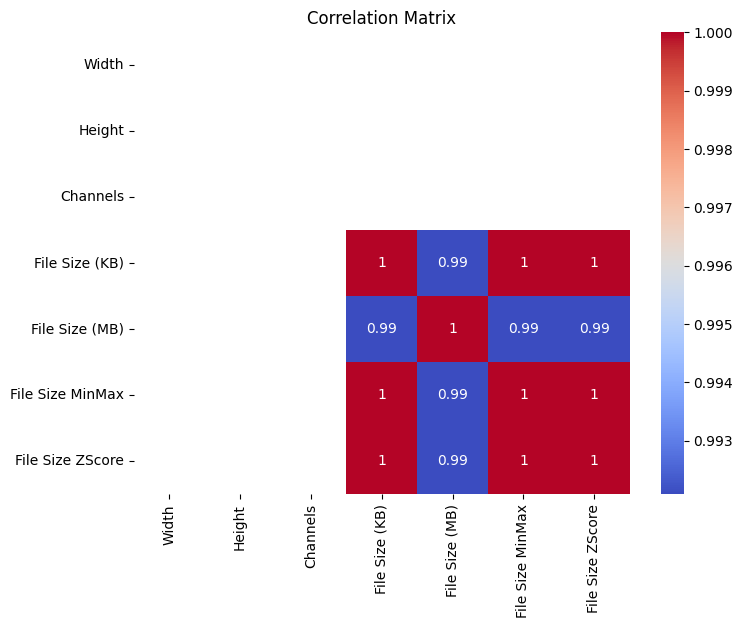

In [21]:
#11. Generate Correlation Matrix and Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

In [22]:
#13. Convert data types wherever necessary (e.g., string to datetime, integer to float)
df['Width'] = df['Width'].astype(float)

df['Height'] = df['Height'].astype(float)

print(df.dtypes)

Split                object
Disease              object
Filename             object
Extension            object
Width               float64
Height              float64
Channels              int64
Color Mode           object
File Size (KB)      float64
File Size (MB)      float64
Full Path            object
File Size MinMax    float64
File Size ZScore    float64
dtype: object


In [23]:
#14. Handle Inconsistent and Noisy Data
df['Disease'] = df['Disease'].str.strip()

df['Color Mode'] = df['Color Mode'].str.upper()

print(df.head())

   Split        Disease      Filename Extension  Width  Height  Channels  \
0  train  Mild_Demented   mild_10.jpg      .jpg  128.0   128.0         1   
1  train  Mild_Demented  mild_100.jpg      .jpg  128.0   128.0         1   
2  train  Mild_Demented  mild_102.jpg      .jpg  128.0   128.0         1   
3  train  Mild_Demented  mild_103.jpg      .jpg  128.0   128.0         1   
4  train  Mild_Demented  mild_106.jpg      .jpg  128.0   128.0         1   

  Color Mode  File Size (KB)  File Size (MB)  \
0          L        4.289609          0.0040   
1          L        3.950000          0.0039   
2          L        3.920000          0.0038   
3          L        3.950000          0.0039   
4          L        4.020000          0.0039   

                                           Full Path  File Size MinMax  \
0  C:\Users\mohib\Desktop\Alzheimer_Split\train\M...          0.560657   
1  C:\Users\mohib\Desktop\Alzheimer_Split\train\M...          0.284553   
2  C:\Users\mohib\Desktop\Alzhei

In [25]:
#15. Split Dataset into Training and Testing Sets
X = df[['Width',
        'Height',
        'Channels',
        'File Size (KB)']]

y = df['Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (5039, 4)
Testing Data Shape : (1260, 4)


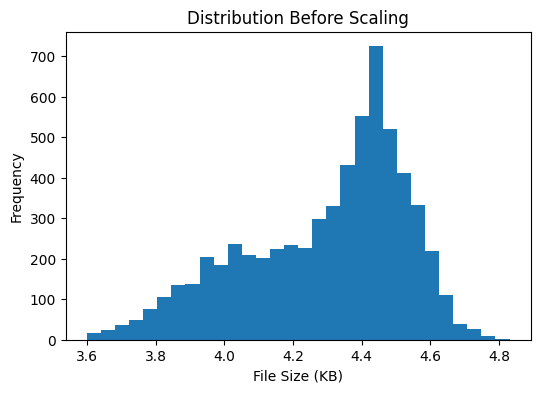

In [26]:
#17. Visualize Distribution Before and After Preprocessing
#(A)Before Scaling
plt.figure(figsize=(6,4))

plt.hist(df['File Size (KB)'], bins=30)

plt.title("Distribution Before Scaling")

plt.xlabel("File Size (KB)")
plt.ylabel("Frequency")

plt.show()

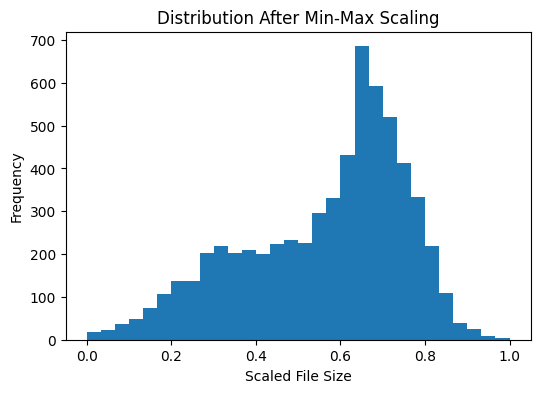

In [27]:
#17. Visualize Distribution Before and After Preprocessing
#(B)After Scaling
plt.figure(figsize=(6,4))

plt.hist(df['File Size MinMax'], bins=30)

plt.title("Distribution After Min-Max Scaling")

plt.xlabel("Scaled File Size")
plt.ylabel("Frequency")

plt.show()

In [28]:
#18. Compare Dataset Before and After Preprocessing
comparison = df[['File Size (KB)',
                 'File Size MinMax',
                 'File Size ZScore']]

print(comparison.head(10))

    File Size (KB)  File Size MinMax  File Size ZScore
0         4.289609          0.560657         -0.020758
1         3.950000          0.284553         -1.460352
2         3.920000          0.260163         -1.587521
3         3.950000          0.284553         -1.460352
4         4.020000          0.341463         -1.163623
6         3.940000          0.276423         -1.502742
7         4.150000          0.447154         -0.612556
8         3.930000          0.268293         -1.545132
9         3.900000          0.243902         -1.672301
10        3.760000          0.130081         -2.265758


In [30]:
#19. Save the Cleaned Dataset
df.to_csv("Alzheimer_Preprocessed.csv", index=False)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.
